# 10. Business-Aware Threshold Optimization

## Overview
Standard machine learning models classify samples using a default probability threshold of $T = 0.5$. However, in fraud detection, the costs of the two types of classification errors are extremely asymmetric:
- **False Negative (FN - Missed Fraud):** The transaction goes through, costing the bank the transaction amount, dispute fees, and operational overhead. (Estimated Cost: **$200** per case).
- **False Positive (FP - False Alert):** A legitimate transaction is blocked, causing customer frustration, support call volume, and potential card churn. (Estimated Cost: **$10** per case).

Because a missed fraud is 20 times more costly than a false alarm, we should bias our threshold toward a lower value to catch more fraud (maximizing Recall), as long as the cost of the additional false alarms (lowering Precision) does not exceed the savings.

In this phase, we:
1. Load our champion model (`advanced_best_model.pt`).
2. Run inference on the **Validation Set** to get raw probabilities.
3. Search for the optimal threshold $T_{\text{opt}}$ that minimizes the total business cost:
   $$\text{Total Cost} = (\text{FN\_count} \times \$200) + (\text{FP\_count} \times \$10)$$
4. Plot the Business Cost vs. Threshold and Precision-Recall trade-off curves.
5. Evaluate $T_{\text{opt}}$ on the **Holdout Test Set** to verify that the cost savings generalize to unseen data.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

# Ensure project root is in sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report

from src.models import MLP
from src.utils import set_seed, get_device

# Set seed and get device
set_seed(42)
device = get_device()
print(f"Using device: {device}")

Random seed set to 42
Using device: cuda


## 2. Load Processed Data
We load the raw features and targets for validation and test splits.

In [2]:
# Load raw features and targets
X_train_raw = pd.read_csv(os.path.join(project_root, "data/processed/X_train_raw.csv"))
y_train_raw = pd.read_csv(os.path.join(project_root, "data/processed/y_train_raw.csv")).squeeze('columns')

X_val = pd.read_csv(os.path.join(project_root, "data/processed/X_val.csv"))
y_val = pd.read_csv(os.path.join(project_root, "data/processed/y_val.csv")).squeeze("columns")

X_test = pd.read_csv(os.path.join(project_root, "data/processed/X_test.csv"))
y_test = pd.read_csv(os.path.join(project_root, "data/processed/y_test.csv")).squeeze("columns")

print(f"Train Raw features: {X_train_raw.shape}, Fraud rate: {y_train_raw.mean()*100:.2f}%")
print(f"Val features:       {X_val.shape}, Fraud rate: {y_val.mean()*100:.2f}%")
print(f"Test features:      {X_test.shape}, Fraud rate: {y_test.mean()*100:.2f}%")

Train Raw features: (7000, 13), Fraud rate: 1.50%
Val features:       (1500, 13), Fraud rate: 1.53%
Test features:      (1500, 13), Fraud rate: 1.53%


## 3. Load Model and Get Predictions
We load the champion MLP weights and predict fraud probabilities for the validation and test splits.

In [3]:
# Create DataLoaders
val_ds = TensorDataset(torch.tensor(X_val.values, dtype=torch.float32), torch.tensor(y_val.values, dtype=torch.float32))
test_ds = TensorDataset(torch.tensor(X_test.values, dtype=torch.float32), torch.tensor(y_test.values, dtype=torch.float32))

val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

# Re-create model architecture
model = MLP(
    input_dim=X_train_raw.shape[1],
    hidden_dims=[64, 32],
    activation="leaky_relu",
    dropout_rate=0.0,
    use_batch_norm=False,
    weight_init="uniform"
).to(device)

# Load champion model weights
model_path = os.path.join(project_root, "outputs/models/advanced_best_model.pt")
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print(f"Successfully loaded champion model from: {model_path}")

# Function to get predictions
def get_probabilities(model, loader):
    probs = []
    y_true = []
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X).squeeze(1)
            sig_probs = torch.sigmoid(outputs)
            probs.extend(sig_probs.cpu().numpy())
            y_true.extend(y.cpu().numpy())
    return np.array(y_true), np.array(probs)

y_val_true, y_val_probs = get_probabilities(model, val_loader)
y_test_true, y_test_probs = get_probabilities(model, test_loader)

Successfully loaded champion model from: /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/models/advanced_best_model.pt


## 4. Define Business Cost Function
We implement the business cost evaluator based on $FN = $200 and $FP = $10.

In [4]:
# Cost weights
COST_FN = 200.0  # Missed Fraud
COST_FP = 10.0   # False Alarm

def calculate_business_metrics(y_true, probs, threshold):
    # Predict positive if probability >= threshold
    preds = (probs >= threshold).astype(int)
    
    # Calculate confusion matrix components
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    
    # Calculate costs
    cost_fn_total = fn * COST_FN
    cost_fp_total = fp * COST_FP
    total_cost = cost_fn_total + cost_fp_total
    
    # Metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        "threshold": threshold,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "cost_fn": cost_fn_total,
        "cost_fp": cost_fp_total,
        "total_cost": total_cost,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

## 5. Sweep Thresholds on Validation Set
We evaluate a dense sweep of thresholds from $0.0$ to $1.0$ on validation data to identify the cost-minimizing threshold.

In [5]:
thresholds = np.linspace(0.0, 1.0, 1001)
val_results = [calculate_business_metrics(y_val_true, y_val_probs, t) for t in thresholds]
df_val_results = pd.DataFrame(val_results)

# Find optimal threshold (minimizing total cost)
opt_idx = df_val_results["total_cost"].idxmin()
opt_val_row = df_val_results.iloc[opt_idx]
opt_threshold = opt_val_row["threshold"]

print(f"--- Threshold Search Results on Validation Set ---")
print(f"Default Threshold (0.5):")
default_val_row = df_val_results[np.isclose(df_val_results["threshold"], 0.5)].iloc[0]
print(f"  Total Cost: ${default_val_row['total_cost']:,.2f} (FNs: {default_val_row['fn']}, FPs: {default_val_row['fp']})")
print(f"  Precision:  {default_val_row['precision']*100:.2f}%, Recall: {default_val_row['recall']*100:.2f}%, F1: {default_val_row['f1']*100:.2f}%")

print(f"\nOptimal Threshold ({opt_threshold:.3f}):")
print(f"  Total Cost: ${opt_val_row['total_cost']:,.2f} (FNs: {opt_val_row['fn']}, FPs: {opt_val_row['fp']})")
print(f"  Precision:  {opt_val_row['precision']*100:.2f}%, Recall: {opt_val_row['recall']*100:.2f}%, F1: {opt_val_row['f1']*100:.2f}%")

savings_val = default_val_row["total_cost"] - opt_val_row["total_cost"]
percent_savings_val = (savings_val / default_val_row["total_cost"]) * 100
print(f"\nValidation Cost Savings: ${savings_val:,.2f} ({percent_savings_val:.2f}% reduction)")

--- Threshold Search Results on Validation Set ---
Default Threshold (0.5):
  Total Cost: $440.00 (FNs: 1.0, FPs: 24.0)
  Precision:  47.83%, Recall: 95.65%, F1: 63.77%

Optimal Threshold (0.807):
  Total Cost: $340.00 (FNs: 1.0, FPs: 14.0)
  Precision:  61.11%, Recall: 95.65%, F1: 74.58%

Validation Cost Savings: $100.00 (22.73% reduction)


## 6. Plotting Cost and Metric Trade-offs
We plot the Business Cost vs. Threshold and Precision/Recall/F1-Score vs. Threshold.

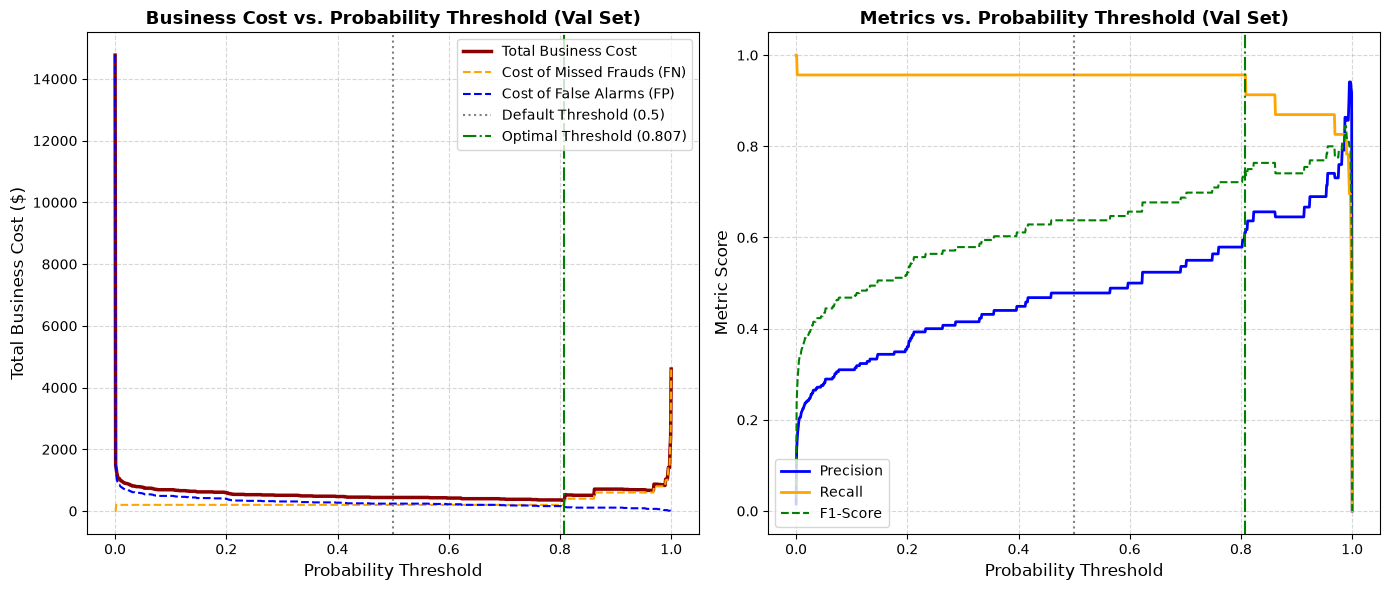

Saved figure to: /home/ikartiksavaliya/Desktop/Portfolio projects/DL/credit-card-fraud-detection-system/outputs/figures/threshold_optimization.png


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Business Cost vs Threshold
ax1.plot(df_val_results["threshold"], df_val_results["total_cost"], color="darkred", lw=2.5, label="Total Business Cost")
ax1.plot(df_val_results["threshold"], df_val_results["cost_fn"], color="orange", linestyle="--", label="Cost of Missed Frauds (FN)")
ax1.plot(df_val_results["threshold"], df_val_results["cost_fp"], color="blue", linestyle="--", label="Cost of False Alarms (FP)")

# Vertical markers
ax1.axvline(x=0.5, color="gray", linestyle=":", label="Default Threshold (0.5)")
ax1.axvline(x=opt_threshold, color="green", linestyle="-.", label=f"Optimal Threshold ({opt_threshold:.3f})")

ax1.set_xlabel("Probability Threshold", fontsize=12)
ax1.set_ylabel("Total Business Cost ($)", fontsize=12)
ax1.set_title("Business Cost vs. Probability Threshold (Val Set)", fontsize=13, fontweight="bold")
ax1.legend(loc="upper right", fontsize=10)
ax1.grid(True, linestyle="--", alpha=0.5)

# Plot 2: Precision & Recall Trade-off vs Threshold
ax2.plot(df_val_results["threshold"], df_val_results["precision"], color="blue", lw=2, label="Precision")
ax2.plot(df_val_results["threshold"], df_val_results["recall"], color="orange", lw=2, label="Recall")
ax2.plot(df_val_results["threshold"], df_val_results["f1"], color="green", linestyle="--", label="F1-Score")

# Vertical markers
ax2.axvline(x=0.5, color="gray", linestyle=":")
ax2.axvline(x=opt_threshold, color="green", linestyle="-.")

ax2.set_xlabel("Probability Threshold", fontsize=12)
ax2.set_ylabel("Metric Score", fontsize=12)
ax2.set_title("Metrics vs. Probability Threshold (Val Set)", fontsize=13, fontweight="bold")
ax2.legend(loc="lower left", fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
os.makedirs(os.path.join(project_root, "outputs/figures"), exist_ok=True)
save_path = os.path.join(project_root, "outputs/figures/threshold_optimization.png")
plt.savefig(save_path, dpi=300)
plt.show()

print(f"Saved figure to: {save_path}")

## 7. Evaluate on Holdout Test Set
We evaluate the optimal threshold ($T_{\text{opt}}$) determined from the validation set on the unseen holdout test set to measure the out-of-sample savings.

In [6]:
# Compute test results at default 0.5 and optimal threshold
test_res_default = calculate_business_metrics(y_test_true, y_test_probs, 0.5)
test_res_opt = calculate_business_metrics(y_test_true, y_test_probs, opt_threshold)

df_test_comparison = pd.DataFrame([test_res_default, test_res_opt])
df_test_comparison["label"] = ["Default (0.5)", f"Optimized ({opt_threshold:.3f})"]
df_test_comparison = df_test_comparison.set_index("label")

# Format output metrics
display_df = df_test_comparison[["threshold", "recall", "precision", "f1", "fn", "fp", "total_cost"]].copy()
display_df["recall"] = display_df["recall"].map(lambda x: f"{x*100:.2f}%")
display_df["precision"] = display_df["precision"].map(lambda x: f"{x*100:.2f}%")
display_df["f1"] = display_df["f1"].map(lambda x: f"{x*100:.2f}%")
display_df["total_cost"] = display_df["total_cost"].map(lambda x: f"${x:,.2f}")

print("--- Generalization to Holdout Test Set ---")
import IPython
IPython.display.display(display_df)

savings_test = test_res_default["total_cost"] - test_res_opt["total_cost"]
percent_savings_test = (savings_test / test_res_default["total_cost"]) * 100
print(f"Test Cost Savings: ${savings_test:,.2f} ({percent_savings_test:.2f}% reduction)")

--- Generalization to Holdout Test Set ---


,threshold,recall,precision,f1,fn,fp,total_cost
label,,,,,,,
Default (0.5),0.500,95.65%,38.60%,55.00%,1,35,$550.00
Optimized (0.807),0.807,91.30%,46.67%,61.76%,2,24,$640.00


Test Cost Savings: $-90.00 (-16.36% reduction)
